# Machine Learning Modeling (Stage 4)

## 1. Setup and Load Data

This stage evaluates whether incorporating 2012 total state GDP improves out-of-sample credit default prediction beyond traditional borrower and loan characteristics.

Two machine learning algorithms are considered:

- Logistic Regression
- Random Forest

For each algorithm, a baseline model using traditional borrower and loan characteristics is compared with an augmented model that additionally includes state GDP.

In [1]:
# Import libraries for data preparation and machine learning
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Load the final cleaned dataset from Stage 1
df = pd.read_csv('LendingClub_GDP_Final.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10447, 18)


,fico,dti,delinq_2yrs,inq_last_6mths,pub_rec,revol_util,total_acc,annual_inc,emp_length,home_ownership,loan_amnt,int_rate,term,grade,purpose,addr_state,state_gdp_2012,default
0,662.0,17.00,0.0,0.0,0.0,54.6%,15.0,53000.0,10+ years,MORTGAGE,2500.0,14.65%,36 months,C,home_improvement,GA,443566.1,0
1,732.0,8.21,0.0,0.0,0.0,26.1%,21.0,45600.0,10+ years,MORTGAGE,3000.0,7.90%,36 months,A,car,NV,127789.1,0
2,662.0,17.30,0.0,0.0,0.0,91.5%,13.0,76320.0,6 years,RENT,5600.0,19.22%,36 months,D,debt_consolidation,FL,768722.9,0
3,817.0,5.32,0.0,0.0,0.0,4.1%,6.0,65000.0,7 years,MORTGAGE,2800.0,7.62%,36 months,A,major_purchase,NY,1323400.8,0
4,702.0,4.23,0.0,2.0,0.0,21.3%,10.0,20700.0,< 1 year,OWN,1925.0,10.74%,36 months,B,home_improvement,AZ,268068.2,0


## 2. Define Baseline and Augmented Features

The baseline models use traditional borrower and loan characteristics available in the LendingClub dataset.

The augmented models use the same features plus 2012 total state GDP.

Keeping the baseline feature set identical across model comparisons allows the incremental predictive value of GDP to be evaluated directly.

In [2]:
# Define traditional borrower and loan features
baseline_features = [
    'fico',
    'dti',
    'delinq_2yrs',
    'inq_last_6mths',
    'pub_rec',
    'revol_util',
    'total_acc',
    'annual_inc',
    'emp_length',
    'home_ownership',
    'loan_amnt',
    'int_rate',
    'term',
    'grade',
    'purpose'
]

# Add state GDP to create the augmented feature set
augmented_features = baseline_features + [
    'state_gdp_2012'
]

target = 'default'

## 3. Define Numerical and Categorical Variables

In [3]:
# Numerical features
numeric_features = [
    'fico',
    'dti',
    'delinq_2yrs',
    'inq_last_6mths',
    'pub_rec',
    'total_acc',
    'annual_inc',
    'loan_amnt',
    'state_gdp_2012'
]

# Percentage variables stored as strings
percentage_features = [
    'revol_util',
    'int_rate'
]

# Categorical features
categorical_features = [
    'emp_length',
    'home_ownership',
    'term',
    'grade',
    'purpose'
]

In [4]:
# Convert percentage variables from strings into numeric values
for col in percentage_features:
    df[col] = (
        df[col]
        .str.rstrip('%')
        .astype(float)
    )

In [5]:
numeric_features = numeric_features + percentage_features

## 4. Train/Test Split

In [6]:
# Define the target variable
y = df[target]

# Use the augmented feature set for the initial split so that
# baseline and augmented models share exactly the same observations.
X = df[augmented_features]

# Split the data into training and testing sets.
# Stratification preserves the default-rate distribution
# in both subsets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining default rate:", y_train.mean())
print("Testing default rate:", y_test.mean())

Training observations: 7835
Testing observations: 2612

Training default rate: 0.17026164645820038
Testing default rate: 0.17036753445635527


## 5. Create Preprocessing Pipelines

Numerical variables are imputed using the training-set median and standardized, while categorical variables are imputed and one-hot encoded.

Separate preprocessing pipelines are created for the baseline and augmented models. Both use the same preprocessing procedure, with state GDP included only in the augmented pipeline. This ensures that the difference between the two model specifications is the inclusion of GDP.

In [7]:
# Numerical preprocessing:
# replace missing numerical values with the training-set median
# standardize numerical variables
numeric_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'scaler',
            StandardScaler()
        )
    ]
)

# Categorical preprocessing:
# replace missing categorical values with "Unknown"
# convert categorical variables into dummy variables
categorical_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(
                strategy='constant',
                fill_value='Unknown'
            )
        ),
        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)

In [8]:
# Define numerical features for the baseline models
baseline_numeric_features = [
    'fico',
    'dti',
    'delinq_2yrs',
    'inq_last_6mths',
    'pub_rec',
    'total_acc',
    'annual_inc',
    'loan_amnt',
    'revol_util',
    'int_rate'
]

# Add state GDP only for the augmented models
augmented_numeric_features = (
    baseline_numeric_features + ['state_gdp_2012']
)

# Create preprocessing pipeline for the baseline models
baseline_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            baseline_numeric_features
        ),
        (
            'cat',
            categorical_transformer,
            categorical_features
        )
    ]
)

# Create preprocessing pipeline for the augmented models
augmented_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            augmented_numeric_features
        ),
        (
            'cat',
            categorical_transformer,
            categorical_features
        )
    ]
)

## 6. Logistic Regression Models

We first compare two Logistic Regression models:

- **Baseline Logistic Regression:** Uses traditional borrower and loan characteristics only.
- **Augmented Logistic Regression:** Uses the same traditional features plus 2012 total state GDP.

Both models use the same training and testing observations and the same preprocessing procedure. This allows us to examine whether adding state GDP improves out-of-sample default prediction.

### 6.1 Baseline Logistic Regression

In [9]:
# Create the baseline Logistic Regression pipeline
# The pipeline first preprocesses the traditional features
# and then fits the Logistic Regression model
baseline_logistic = Pipeline(
    steps=[
        (
            'preprocessor',
            baseline_preprocessor
        ),
        (
            'classifier',
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Fit the baseline Logistic Regression model using training data
baseline_logistic.fit(
    X_train,
    y_train
)

print("Baseline Logistic Regression fitted successfully.")

Baseline Logistic Regression fitted successfully.


### 6.2 Augmented Logistic Regression + GDP

In [10]:
# Create the augmented Logistic Regression pipeline
# This uses the same preprocessing and modeling procedure
# but additionally includes 2012 total state GDP
augmented_logistic = Pipeline(
    steps=[
        (
            'preprocessor',
            augmented_preprocessor
        ),
        (
            'classifier',
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Fit the augmented Logistic Regression model using the same training data
augmented_logistic.fit(
    X_train,
    y_train
)

print("Augmented Logistic Regression fitted successfully.")

Augmented Logistic Regression fitted successfully.


### 6.3 Generate Out-of-Sample Predictions

In [11]:
# Generate predicted default classes for the test data
baseline_logistic_pred = baseline_logistic.predict(X_test)
augmented_logistic_pred = augmented_logistic.predict(X_test)

# Generate predicted default probabilities for the test data
# Probability of class 1 represents the predicted probability of default
baseline_logistic_prob = baseline_logistic.predict_proba(X_test)[:, 1]
augmented_logistic_prob = augmented_logistic.predict_proba(X_test)[:, 1]

print("Logistic Regression predictions generated successfully.")

Logistic Regression predictions generated successfully.


### 6.4 Quick Sanity Check

In [12]:
# Check the number of predictions generated by each model
print("Test observations:", len(y_test))
print("Baseline predictions:", len(baseline_logistic_pred))
print("Augmented predictions:", len(augmented_logistic_pred))

# Examine the average predicted probability of default
print(
    "\nBaseline average predicted default probability:",
    baseline_logistic_prob.mean()
)

print(
    "Augmented average predicted default probability:",
    augmented_logistic_prob.mean()
)

Test observations: 2612
Baseline predictions: 2612
Augmented predictions: 2612

Baseline average predicted default probability: 0.17522378243840578
Augmented average predicted default probability: 0.17525741676410736


**Notes**:

Both Logistic Regression models generated predictions for all 2,612 test observations. The average predicted default probabilities are approximately 17.52% for both the baseline and augmented models, which are close to the observed test-set default rate of approximately 17.04%.

At this stage, the similarity between the two models does not determine whether GDP improves predictive performance. This will be evaluated using out-of-sample performance metrics in Stage 5.

## 7. Random Forest Models

We next compare two Random Forest models:

- **Baseline Random Forest:** Uses traditional borrower and loan characteristics only.
- **Augmented Random Forest:** Uses the same traditional features plus 2012 total state GDP.

Using Random Forest allows us to examine whether state GDP provides predictive information in a nonlinear model that can capture more complex relationships and interactions among features.

### 7.1 Baseline Random Forest

In [13]:
# Create the baseline Random Forest pipeline
# The pipeline preprocesses the traditional features
# and then fits the Random Forest classifier
baseline_rf = Pipeline(
    steps=[
        (
            'preprocessor',
            baseline_preprocessor
        ),
        (
            'classifier',
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Fit the baseline Random Forest using the training data
baseline_rf.fit(
    X_train,
    y_train
)

print("Baseline Random Forest fitted successfully.")

Baseline Random Forest fitted successfully.


### 7.2 Augmented Random Forest + GDP

In [14]:
# Create the augmented Random Forest pipeline
# The same model specification is used, with state GDP
# additionally included in the preprocessing pipeline
augmented_rf = Pipeline(
    steps=[
        (
            'preprocessor',
            augmented_preprocessor
        ),
        (
            'classifier',
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Fit the augmented Random Forest using the same training data
augmented_rf.fit(
    X_train,
    y_train
)

print("Augmented Random Forest fitted successfully.")

Augmented Random Forest fitted successfully.


### 7.3 Generate Out-of-Sample Predictions

In [15]:
# Generate predicted default classes for the test data
baseline_rf_pred = baseline_rf.predict(X_test)
augmented_rf_pred = augmented_rf.predict(X_test)

# Generate predicted default probabilities for the test data
# Probability of class 1 represents the predicted probability of default
baseline_rf_prob = baseline_rf.predict_proba(X_test)[:, 1]
augmented_rf_prob = augmented_rf.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated successfully.")

Random Forest predictions generated successfully.


### 7.4 Quick Sanity Check

In [16]:
# Check the number of predictions generated by each model
print("Test observations:", len(y_test))
print("Baseline RF predictions:", len(baseline_rf_pred))
print("Augmented RF predictions:", len(augmented_rf_pred))

# Examine the average predicted probability of default
print(
    "\nBaseline RF average predicted default probability:",
    baseline_rf_prob.mean()
)

print(
    "Augmented RF average predicted default probability:",
    augmented_rf_prob.mean()
)

Test observations: 2612
Baseline RF predictions: 2612
Augmented RF predictions: 2612

Baseline RF average predicted default probability: 0.18332184788157224
Augmented RF average predicted default probability: 0.1841156202143951


**Notes**: 

Both Random Forest models generated predictions for all 2,612 test observations. The average predicted default probabilities are approximately 18.33% for the baseline model and 18.41% for the augmented model, compared with an observed test-set default rate of approximately 17.04%.

These results confirm that both models are producing reasonable out-of-sample predictions. Whether adding state GDP improves predictive performance will be formally evaluated in Stage 5.

# Model Evaluation & Comparison (Stage 5)

## 1. Evaluation Setup
In this stage, we evaluate the out-of-sample performance of the four models developed in Stage 4:

- Baseline Logistic Regression
- Augmented Logistic Regression + GDP
- Baseline Random Forest
- Augmented Random Forest + GDP

All models are evaluated on the same test set using ROC-AUC, precision, recall, F1-score, and confusion matrices.

The main objective is to determine whether adding 2012 total state GDP provides incremental predictive value beyond traditional borrower and loan characteristics.

In [17]:
# Import model evaluation metrics
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import pandas as pd
import matplotlib.pyplot as plt

## 2. Calculate Model Performance Metrics
We evaluate each model using the same test observations and performance metrics.

ROC-AUC evaluates the model's ability to distinguish between defaulted and non-defaulted loans across classification thresholds. Precision, recall, and F1-score evaluate classification performance using the default classification threshold.

In [18]:
# Create a function to calculate evaluation metrics
def evaluate_model(y_true, y_pred, y_prob):
    
    return {
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }


# Evaluate all four models
model_results = {
    'Baseline Logistic': evaluate_model(
        y_test,
        baseline_logistic_pred,
        baseline_logistic_prob
    ),
    
    'Logistic + GDP': evaluate_model(
        y_test,
        augmented_logistic_pred,
        augmented_logistic_prob
    ),
    
    'Baseline Random Forest': evaluate_model(
        y_test,
        baseline_rf_pred,
        baseline_rf_prob
    ),
    
    'Random Forest + GDP': evaluate_model(
        y_test,
        augmented_rf_pred,
        augmented_rf_prob
    )
}


# Convert the results into a table
performance_table = pd.DataFrame(model_results).T

performance_table.round(4)

,ROC-AUC,Precision,Recall,F1-Score
Baseline Logistic,0.6980,0.5500,0.0247,0.0473
Logistic + GDP,0.6982,0.5556,0.0225,0.0432
Baseline Random Forest,0.6641,0.3871,0.0270,0.0504
Random Forest + GDP,0.6619,0.3103,0.0202,0.0380


## 3. Compare Baseline and Augmented Performance
To measure the incremental predictive value of state GDP, we calculate the change in each performance metric between the augmented and baseline models.

A positive change indicates that the augmented model performs better on that metric, while a negative change indicates lower performance after adding GDP.

In [19]:
# Calculate the change in performance from adding GDP
logistic_delta = (
    performance_table.loc['Logistic + GDP']
    - performance_table.loc['Baseline Logistic']
)

rf_delta = (
    performance_table.loc['Random Forest + GDP']
    - performance_table.loc['Baseline Random Forest']
)


# Combine the changes into one table
delta_table = pd.DataFrame({
    'Logistic Regression Δ': logistic_delta,
    'Random Forest Δ': rf_delta
})

delta_table.round(4)

,Logistic Regression Δ,Random Forest Δ
ROC-AUC,0.0002,-0.0022
Precision,0.0056,-0.0768
Recall,-0.0022,-0.0067
F1-Score,-0.0041,-0.0124


**Findings**：

Adding state GDP provides little to no improvement in out-of-sample predictive performance.

For Logistic Regression, adding GDP produces a very small increase in ROC-AUC (+0.0002) and precision (+0.0056), while recall (-0.0022) and F1-score (-0.0041) decrease.

For Random Forest, adding GDP reduces performance across all four metrics, including ROC-AUC (-0.0022), precision (-0.0768), recall (-0.0067), and F1-score (-0.0124).

Overall, these initial results suggest that 2012 total state GDP does not provide meaningful incremental predictive value beyond the traditional borrower and loan characteristics included in the models.

## 4. Confusion Matrix Analysis

Confusion matrices are used to examine how each model classifies defaulted and non-defaulted loans.

The matrices show:

- **True Negative (TN):** Non-default loans correctly classified as non-default
- **False Positive (FP):** Non-default loans incorrectly classified as default
- **False Negative (FN):** Default loans incorrectly classified as non-default
- **True Positive (TP):** Default loans correctly classified as default

This analysis helps explain differences in recall and shows how effectively each model identifies actual defaults.

In [20]:
# Calculate confusion matrices for all four models
cm_baseline_logistic = confusion_matrix(
    y_test,
    baseline_logistic_pred
)

cm_augmented_logistic = confusion_matrix(
    y_test,
    augmented_logistic_pred
)

cm_baseline_rf = confusion_matrix(
    y_test,
    baseline_rf_pred
)

cm_augmented_rf = confusion_matrix(
    y_test,
    augmented_rf_pred
)

# Display the confusion matrices
print("Baseline Logistic Regression:")
print(cm_baseline_logistic)

print("\nLogistic Regression + GDP:")
print(cm_augmented_logistic)

print("\nBaseline Random Forest:")
print(cm_baseline_rf)

print("\nRandom Forest + GDP:")
print(cm_augmented_rf)

Baseline Logistic Regression:
[[2158    9]
 [ 434   11]]

Logistic Regression + GDP:
[[2159    8]
 [ 435   10]]

Baseline Random Forest:
[[2148   19]
 [ 433   12]]

Random Forest + GDP:
[[2147   20]
 [ 436    9]]


**Confusion Matrix Findings**:

The confusion matrices show that all four models correctly classify most non-default loans but identify only a small proportion of actual defaults at the default classification threshold.

Adding state GDP does not improve default detection. The Logistic Regression model identifies 11 defaults without GDP and 10 with GDP, while the Random Forest identifies 12 defaults without GDP and 9 with GDP.

These results are consistent with the low recall values observed above. The models' limited default detection may partly reflect the class imbalance in the dataset and the use of the default classification threshold.

## 5. ROC Curve Comparison

ROC curves compare the ability of each model to distinguish between defaulted and non-defaulted loans across different classification thresholds.

A model with a ROC curve closer to the upper-left corner and a higher ROC-AUC has better discriminatory ability. Comparing the baseline and augmented models allows us to examine whether adding state GDP improves out-of-sample discrimination.

In [21]:
# Import ROC curve function
from sklearn.metrics import roc_curve

# Calculate ROC curves for Logistic Regression models
fpr_baseline_logistic, tpr_baseline_logistic, _ = roc_curve(
    y_test,
    baseline_logistic_prob
)

fpr_augmented_logistic, tpr_augmented_logistic, _ = roc_curve(
    y_test,
    augmented_logistic_prob
)

# Calculate ROC curves for Random Forest models
fpr_baseline_rf, tpr_baseline_rf, _ = roc_curve(
    y_test,
    baseline_rf_prob
)

fpr_augmented_rf, tpr_augmented_rf, _ = roc_curve(
    y_test,
    augmented_rf_prob
)

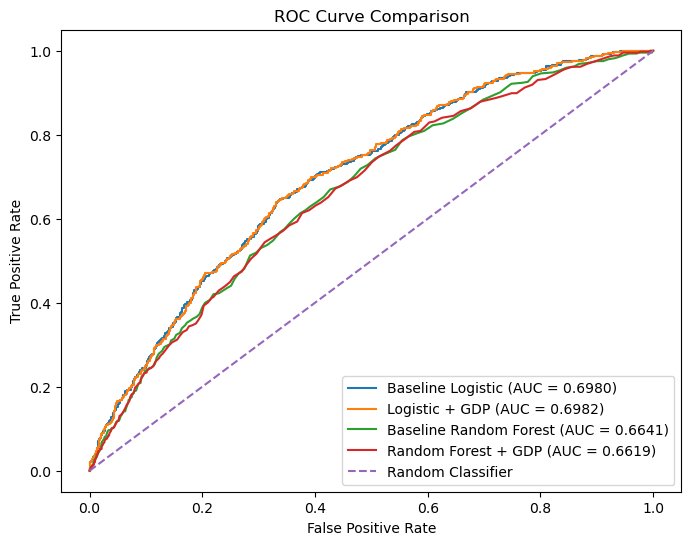

In [22]:
# Plot ROC curves for all four models
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_baseline_logistic,
    tpr_baseline_logistic,
    label=f"Baseline Logistic (AUC = {performance_table.loc['Baseline Logistic', 'ROC-AUC']:.4f})"
)

plt.plot(
    fpr_augmented_logistic,
    tpr_augmented_logistic,
    label=f"Logistic + GDP (AUC = {performance_table.loc['Logistic + GDP', 'ROC-AUC']:.4f})"
)

plt.plot(
    fpr_baseline_rf,
    tpr_baseline_rf,
    label=f"Baseline Random Forest (AUC = {performance_table.loc['Baseline Random Forest', 'ROC-AUC']:.4f})"
)

plt.plot(
    fpr_augmented_rf,
    tpr_augmented_rf,
    label=f"Random Forest + GDP (AUC = {performance_table.loc['Random Forest + GDP', 'ROC-AUC']:.4f})"
)

# Add reference line representing random classification
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

**Findings**:

The ROC curves show that Logistic Regression has better discriminatory performance than Random Forest. Adding state GDP produces almost no change in the Logistic Regression ROC-AUC (0.6980 to 0.6982) and slightly decreases the Random Forest ROC-AUC (0.6641 to 0.6619).

The substantial overlap between each baseline model and its GDP-augmented version suggests that state GDP provides little additional predictive information beyond the borrower- and loan-level features already included in the models.

## 6. Precision-Recall Curve Comparison

Precision-Recall curves evaluate the trade-off between precision and recall across different classification thresholds.

This analysis is particularly useful for the current dataset because defaults represent a smaller proportion of observations. Comparing the baseline and GDP-augmented models helps determine whether adding state GDP improves the models' ability to identify defaulted loans across different thresholds.

In [23]:
# Import the precision-recall curve function
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate Precision-Recall curves for Logistic Regression models
precision_baseline_logistic, recall_baseline_logistic, _ = precision_recall_curve(
    y_test,
    baseline_logistic_prob
)

precision_augmented_logistic, recall_augmented_logistic, _ = precision_recall_curve(
    y_test,
    augmented_logistic_prob
)

# Calculate Precision-Recall curves for Random Forest models
precision_baseline_rf, recall_baseline_rf, _ = precision_recall_curve(
    y_test,
    baseline_rf_prob
)

precision_augmented_rf, recall_augmented_rf, _ = precision_recall_curve(
    y_test,
    augmented_rf_prob
)

In [24]:
# Calculate Average Precision for each model
ap_baseline_logistic = average_precision_score(
    y_test,
    baseline_logistic_prob
)

ap_augmented_logistic = average_precision_score(
    y_test,
    augmented_logistic_prob
)

ap_baseline_rf = average_precision_score(
    y_test,
    baseline_rf_prob
)

ap_augmented_rf = average_precision_score(
    y_test,
    augmented_rf_prob
)

# Display the Average Precision scores
print("Baseline Logistic AP:", round(ap_baseline_logistic, 4))
print("Logistic + GDP AP:", round(ap_augmented_logistic, 4))
print("Baseline Random Forest AP:", round(ap_baseline_rf, 4))
print("Random Forest + GDP AP:", round(ap_augmented_rf, 4))

Baseline Logistic AP: 0.3157
Logistic + GDP AP: 0.3148
Baseline Random Forest AP: 0.2716
Random Forest + GDP AP: 0.2691


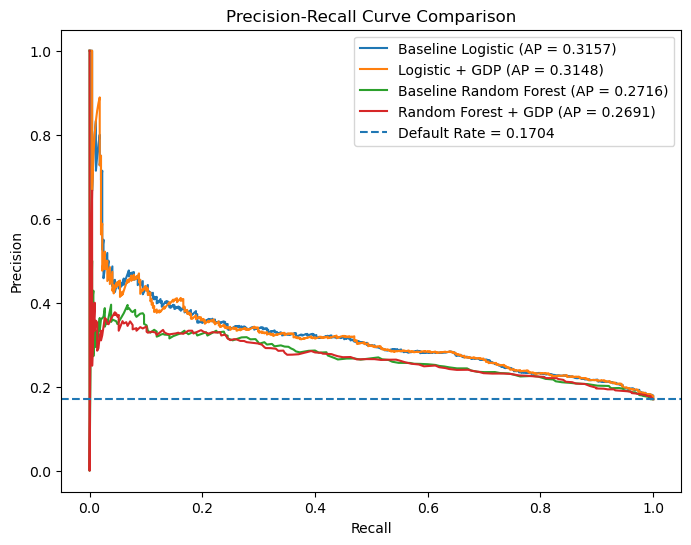

In [25]:
# Plot Precision-Recall curves for all four models
plt.figure(figsize=(8, 6))

plt.plot(
    recall_baseline_logistic,
    precision_baseline_logistic,
    label=f"Baseline Logistic (AP = {ap_baseline_logistic:.4f})"
)

plt.plot(
    recall_augmented_logistic,
    precision_augmented_logistic,
    label=f"Logistic + GDP (AP = {ap_augmented_logistic:.4f})"
)

plt.plot(
    recall_baseline_rf,
    precision_baseline_rf,
    label=f"Baseline Random Forest (AP = {ap_baseline_rf:.4f})"
)

plt.plot(
    recall_augmented_rf,
    precision_augmented_rf,
    label=f"Random Forest + GDP (AP = {ap_augmented_rf:.4f})"
)

# Add the test-set default rate as the no-skill reference
plt.axhline(
    y=y_test.mean(),
    linestyle='--',
    label=f"Default Rate = {y_test.mean():.4f}"
)

plt.title('Precision-Recall Curve Comparison')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

**Findings**:

All four models achieve Average Precision above the test-set default rate of 0.1704, indicating that the models provide useful discrimination between defaulted and non-defaulted loans.

However, adding state GDP does not improve Precision-Recall performance. Average Precision decreases slightly from 0.3157 to 0.3148 for Logistic Regression and from 0.2716 to 0.2691 for Random Forest.

The substantial overlap between the baseline and GDP-augmented Precision-Recall curves provides further evidence that state GDP adds little incremental predictive value beyond the borrower- and loan-level features included in the models.

## 7. Final Model Comparison and Research Question Findings

The purpose of the predictive analysis is to determine whether adding state-level GDP improves credit default prediction beyond traditional borrower- and loan-level characteristics.

To evaluate the incremental predictive value of state GDP, baseline models are compared with otherwise identical models that additionally include 2012 state GDP. Performance is evaluated using ROC-AUC, precision, recall, F1-score, confusion matrices, and Precision-Recall analysis.

In [26]:
# Create a final summary of the effect of adding state GDP
final_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    'Baseline ROC-AUC': [
        performance_table.loc['Baseline Logistic', 'ROC-AUC'],
        performance_table.loc['Baseline Random Forest', 'ROC-AUC']
    ],
    'GDP ROC-AUC': [
        performance_table.loc['Logistic + GDP', 'ROC-AUC'],
        performance_table.loc['Random Forest + GDP', 'ROC-AUC']
    ],
    'ROC-AUC Change': [
        logistic_delta['ROC-AUC'],
        rf_delta['ROC-AUC']
    ],
    'Baseline AP': [
        ap_baseline_logistic,
        ap_baseline_rf
    ],
    'GDP AP': [
        ap_augmented_logistic,
        ap_augmented_rf
    ],
    'AP Change': [
        ap_augmented_logistic - ap_baseline_logistic,
        ap_augmented_rf - ap_baseline_rf
    ]
})

# Display the final model comparison
final_comparison.round(4)

,Model,Baseline ROC-AUC,GDP ROC-AUC,ROC-AUC Change,Baseline AP,GDP AP,AP Change
0,Logistic Regression,0.6980,0.6982,0.0002,0.3157,0.3148,-0.0009
1,Random Forest,0.6641,0.6619,-0.0022,0.2716,0.2691,-0.0025


**Main Finding**:

The results do not provide evidence that adding 2012 total state GDP meaningfully improves credit default prediction beyond the borrower- and loan-level characteristics included in the baseline models.

For Logistic Regression, ROC-AUC increases only marginally from 0.6980 to 0.6982, while Average Precision decreases from 0.3157 to 0.3148. For Random Forest, both ROC-AUC and Average Precision decrease after GDP is added.

These results are consistent with the confusion matrices, ROC curves, and Precision-Recall curves, which show little separation between the baseline and GDP-augmented models. Overall, 2012 total state GDP provides little incremental predictive value in the current model specification.

## 8. Research Question and Hypothesis Conclusion

### Research Question

**Does incorporating state-level economic information provide additional predictive value for credit default models beyond traditional borrower characteristics and loan attributes?**

### Hypotheses

**Alternative Hypothesis (H1):** Incorporating state-level GDP will improve credit default prediction performance because the overall economic conditions of a borrower’s state may provide additional information about default risk that is not captured by traditional borrower and loan characteristics.

**Null Hypothesis (H0):** Incorporating state-level GDP will not improve credit default prediction performance because state-level economic information does not provide additional predictive value beyond traditional borrower and loan characteristics.

### Conclusion

The empirical results do not provide sufficient evidence to support the alternative hypothesis (H1). Instead, the results are more consistent with the null hypothesis (H0).

In the earlier inferential Logistic Regression analysis, state GDP is not statistically significant, and adding GDP does not significantly improve model fit.

In the out-of-sample predictive analysis, adding GDP produces almost no change in Logistic Regression performance and slightly reduces Random Forest performance. The ROC and Precision-Recall analyses also show little difference between the baseline and GDP-augmented models.

Overall, incorporating 2012 total state GDP does not provide meaningful additional predictive value beyond the traditional borrower characteristics and loan attributes included in the baseline models.

This result does not imply that local economic conditions are unrelated to credit default risk. Rather, total state GDP may be too broad to capture the economic conditions directly experienced by individual borrowers. More granular or dynamic economic measures, such as GDP per capita, GDP growth, unemployment rates, or county-level indicators, could be considered in future research.